In [1]:
# 1. Sampling Distributions


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# What is sampling?

# Sampling is a statistical method that allows us to infer information about a population based on the statistics from a subset of the 
# population (a sample), without having to measure every individual in the population.

# In the real world, sampling is used in many fields, including polling. For example, pollsters don't ask every eligible voter who they're 
# voting for. Instead, they ask a small, randomly selected sample of voters, and use the results to estimate the preferences of the entire population.

# Under ideal conditions, samples are random, meaning each member of the population has an equal chance of being included in the sample. 
# This ensures that the sample is representative of the population.


# Sample Statistics

# A sample statistic is a measure that summarizes a data sample. The most common sample statistic is the mean (average), 
# which provides a measure of central tendency for the data.

# Some other common sample statistics are the median, mode, and range.

# Basically, any of the numeric aggregation methods that we can perform on Pandas Series object can be a sample statistic.



# Simulating Sampling Distributions

# If we assume that the population follows some known distribution, like a Bernoulli or a Normal distribution, then we can imagine drawing 
# making a fixed number of draws from that distribution, call it n, the sample size, and computing the statistic for that sample. 
# For simplicity, let's focus on the mean, the average, as the sample statistic.

# This process of drawing a sample of size n and computing the mean can be repeated as many times as we like. We could simulate lots of 
# draws of n items, and see how frequently we get different values for the mean. Thus, given an underlying distribution like Bernoulli 
# or Normal, we have a data generating process for computing the mean of a random draw of n items from the population. In other words, 
# we can simulate draws from what is called the sampling distribution of the mean. We will get a different sampling distribution for 
# samples of different sizes, as we will see in a later lesson.

# Let's use our Python machinery to calculate these sampling distributions.

rng = np.random.default_rng(42)

def draw_bernoulli(p, n):
    # Generate the random draws
    # using the numpy random number generator rather than scipy.stats.bernoulli...
    draws = rng.choice([0,1], size=n, p = [1-p, p])
    # Create a pandas DataFrame
    return pd.DataFrame(draws, columns=["Outcome"])



In [2]:
# Let's draw a sample of size 10 and compute its mean value
sample_size = 10
df = draw_bernoulli(0.5, sample_size)
df

,Outcome
0,1
1,0
2,1
3,1
4,0
5,1
6,1
7,1
8,0
9,0


In [3]:
df["Outcome"].mean()

np.float64(0.6)

In [4]:
# Let's do that lots of times
n_simulations=20
samples = [draw_bernoulli(0.5, sample_size) for _ in range(n_simulations)] # generate 20 samples of size 10; returns a Series
pd.DataFrame(  # create a dataframe from the mean value of each of the 20 samples of size 10
    {
        "statistic": [sample["Outcome"].mean() for sample in samples],
    }
)


,statistic
0,0.6
1,0.5
2,0.3
3,0.5
4,0.5
5,0.6
6,0.4
7,0.4
8,0.3
9,0.6


In [5]:
# Abstraction

# We just did something very specific, with a Bernoulli distribution and taking the mean as the sample statistic for each sample.

# In our ongoing quest to follow the motto, "Don't repeat yourself", let's make a more general function that will work for any underlying distribution.

def simulate_sampling_distribution( underlying_distribution_simulator, sample_statistic, n_simulations=1000, sample_size=100 ):
    samples = [underlying_distribution_simulator(sample_size) for _ in range(n_simulations)]
    return pd.DataFrame(
        {
            "statistic": [sample_statistic(sample) for sample in samples],
        }
    )


df = simulate_sampling_distribution(
    underlying_distribution_simulator=lambda n: draw_bernoulli(0.5, n),
    sample_statistic=lambda df: df["Outcome"].mean(),
    n_simulations=20,
    sample_size=10,
)
df

,statistic
0,0.6
1,0.5
2,0.5
3,0.6
4,0.5
5,0.2
6,0.5
7,0.2
8,0.8
9,0.5


In [6]:
# Let's simulate the sampling distribution for the count of 1s, rather than for the mean.
df = simulate_sampling_distribution(
    underlying_distribution_simulator=lambda n: draw_bernoulli(0.5, n),
    sample_statistic=lambda df: df["Outcome"].sum(),  # sum of 0s and 1s is the count of 1s
    n_simulations=10,
    sample_size=10,
)
df

,statistic
0,5
1,5
2,7
3,6
4,5
5,7
6,2
7,3
8,7
9,7


In [7]:
def plot_discrete(data, ax, colname="statistic", num_ticks=None):
    # Create the bar plot on the first y-axis
    counts = data[colname].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax)

    # keep a limited set of labeled ticks on the x-axis, evenly spaced, for legibility
    if num_ticks is not None:
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))



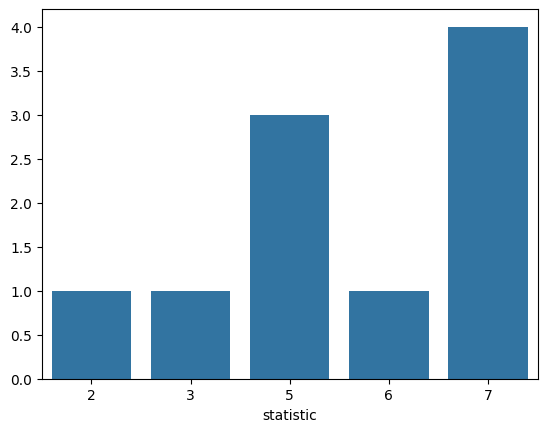

In [8]:
plot_discrete(df, plt.gca())

In [9]:
def plot_discrete(data, ax, colname="statistic", num_ticks=None, min_x=None, max_x=None):
    sns.histplot(data, x=colname, ax=ax)

    # keep a limited set of labeled ticks on the x-axis, evenly spaced, for legibility
    if num_ticks is not None:
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

    # Set the range of the x-axis if min_x and max_x are provided
    if min_x is not None and max_x is not None:
        ax.set_xlim(min_x, max_x)



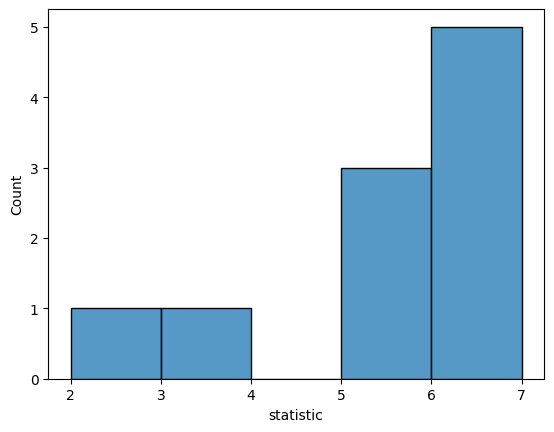

In [10]:
plot_discrete(df, plt.gca())

In [11]:
# The Binomial Distribution

# The sampling distribution for the count of positive outcomes from n flips of a coin has its own name, the Binomial Distribution.
# The binomial distribution takes two parameters, the number of flips, n, and the probability of heads on each flip, p.


def binomial(n, p, n_simulations=1000):
    return simulate_sampling_distribution(
        underlying_distribution_simulator=lambda sample_size: draw_bernoulli(
            p, sample_size
        ),
        sample_statistic=lambda df: df["Outcome"].sum(),
        n_simulations=n_simulations,
        sample_size=n,
    )


In [12]:
binomial(10, 0.5)

,statistic
0,3
1,5
2,5
3,5
4,2
...,...
995,4
996,4
997,6
998,6


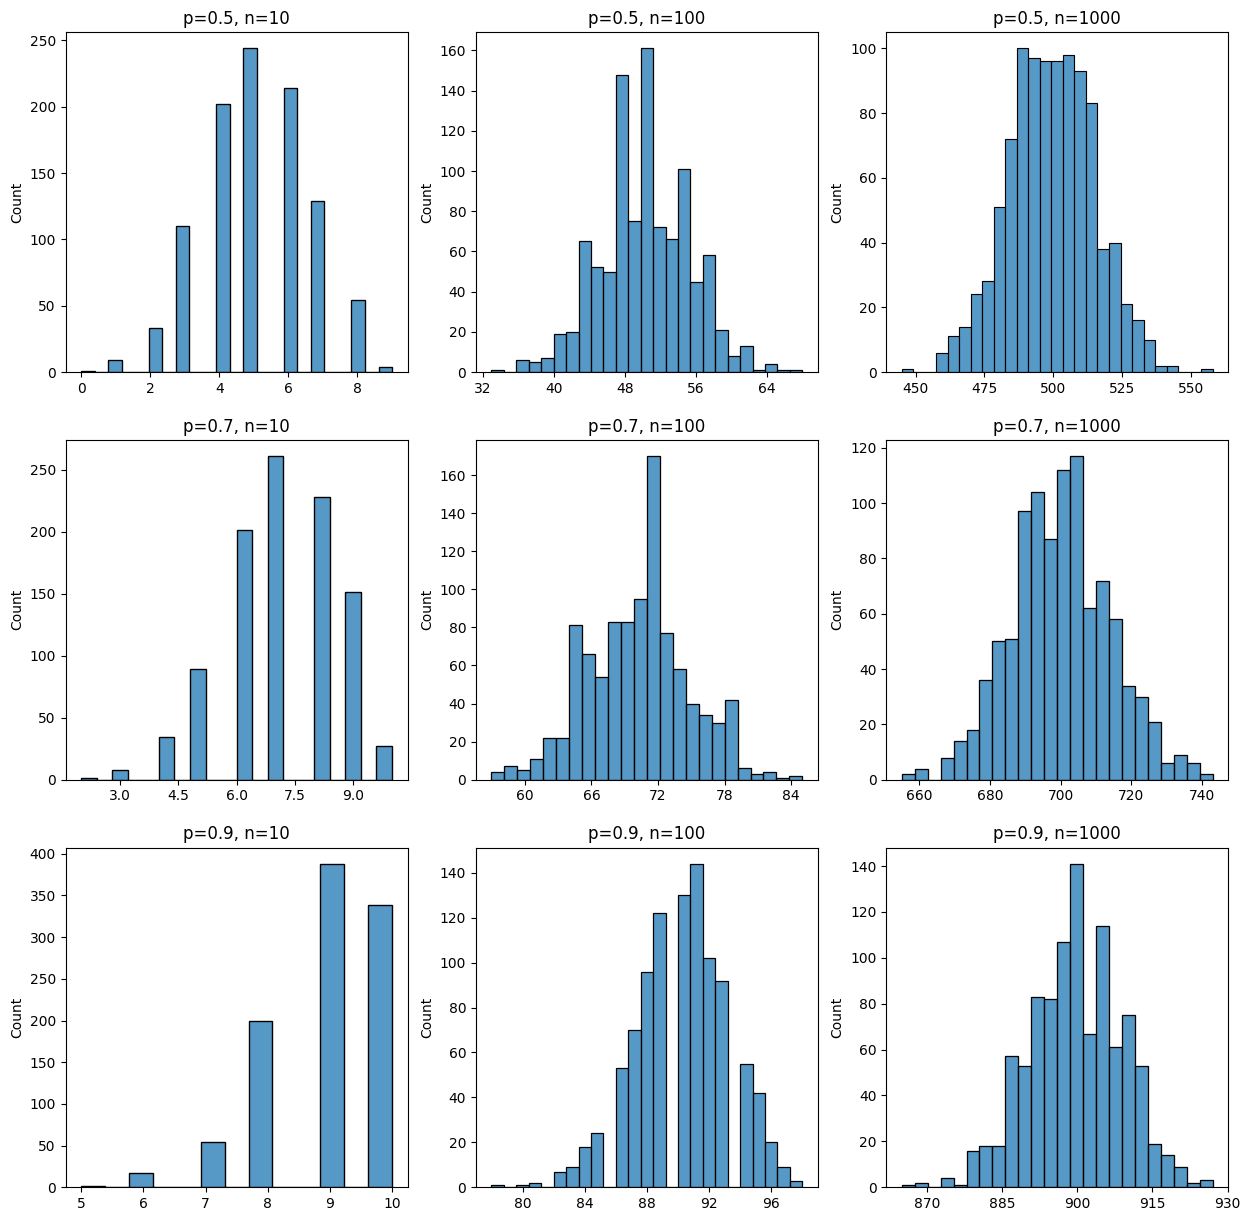

In [13]:
# Let's develop some intuitions about how the binomial distribution changes as we vary n and p

np.random.seed(42)

# make a 3x3 grid of plots
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
# try p in [0.5, .7, .9] and n in [10, 100, 1000]
for i, p in enumerate([0.5, 0.7, 0.9]):
    for j, n in enumerate([10, 100, 1000]):
        df = binomial(n, p)
        plot_discrete(df, axes[i, j], num_ticks=6)
        axes[i, j].set_title(f"p={p}, n={n}")
        axes[i,j].set_xlabel("")



# Some observations:
# - as we increase the sample size, the result gets closer to the mean, with less dispersion.
# - as we increase the chances of getting a head, the distribution shifted to the right.

In [14]:
# There's actually a built-in object for the binomial distribution, in both numpy and scipy!
# I (re)defined it in this notebook so you could understand it as an example of a sampling distribution. But in practice we would actually just use the built-in method.


def binomial(n, p, n_simulations=1000):
    return pd.DataFrame(
        {
            "statistic": rng.binomial(n, p, size=n_simulations),
        }
    )


In [15]:
binomial(10, 0.7)

,statistic
0,8
1,6
2,10
3,5
4,6
...,...
995,9
996,6
997,9
998,5


In [16]:
df = binomial(10, 0.7, n_simulations=1000000)
df["statistic"].value_counts().sort_index()

statistic
0          2
1        148
2       1480
3       8981
4      36989
5     102093
6     201035
7     266987
8     232987
9     120901
10     28397
Name: count, dtype: int64

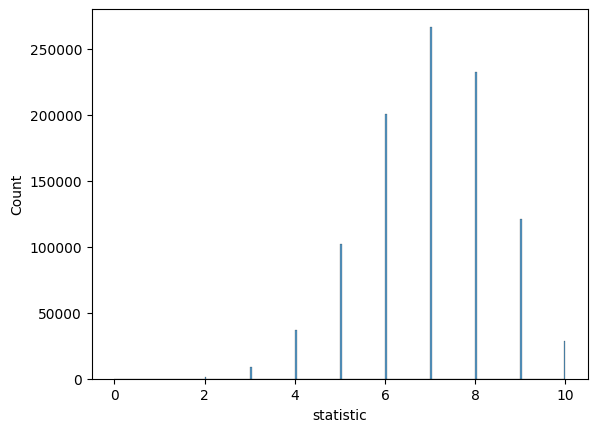

In [17]:
plot_discrete(df, plt.gca())

In [18]:
# 2. How Sample Size affects Variance of the Sampling Distribution


# The Relationship Between Sample Size and Variance (of the Sampling Distribution)

# If we flip a coin 10 times, we won't be surprised if we don't get exactly five heads and five tails. Maybe we get 7 and 3.
# But if we flip the coin 10,000 times, we'll be pretty surprised if we get 70% heads.
# Or, to put it in the context of voter polling, if we take a poll of 10 people and 7 say they prefer candidate A, we won't 
# be very surprised if election day comes and candidate A gets only 45% of the vote.

# But if we took a poll with a random sample of 10,000 voters, and 70% say they prefer candidate A, we will be pretty surprised by an outcome of A losing.
# So, what's going on? As usual, let's use python code and our sampling framework to help build up our intuitions.


# draw from sampling distribution with p=.7 and different sample sizes
small, medium, large = [
    simulate_sampling_distribution(
        underlying_distribution_simulator=lambda n: draw_bernoulli(0.7, n),
        sample_statistic=lambda df: df["Outcome"].mean(),
        n_simulations=10000,
        sample_size=n,
    )
    for n in [10, 100, 10000]
]


small

,statistic
0,0.5
1,0.4
2,0.6
3,0.7
4,0.7
...,...
9995,0.7
9996,0.5
9997,0.7
9998,0.5


In [19]:
small.value_counts(normalize=True).sort_index()

statistic
0.1          0.0002
0.2          0.0016
0.3          0.0084
0.4          0.0352
0.5          0.1049
0.6          0.2011
0.7          0.2640
0.8          0.2332
0.9          0.1212
1.0          0.0302
Name: proportion, dtype: float64

In [20]:
medium.value_counts(normalize=True).sort_index()

statistic
0.52         0.0001
0.53         0.0001
0.54         0.0004
0.55         0.0009
0.56         0.0011
0.57         0.0015
0.58         0.0029
0.59         0.0061
0.60         0.0093
0.61         0.0137
0.62         0.0199
0.63         0.0284
0.64         0.0324
0.65         0.0482
0.66         0.0568
0.67         0.0728
0.68         0.0723
0.69         0.0883
0.70         0.0844
0.71         0.0888
0.72         0.0815
0.73         0.0696
0.74         0.0590
0.75         0.0500
0.76         0.0361
0.77         0.0264
0.78         0.0210
0.79         0.0118
0.80         0.0084
0.81         0.0046
0.82         0.0019
0.83         0.0008
0.84         0.0003
0.85         0.0001
0.86         0.0001
Name: proportion, dtype: float64

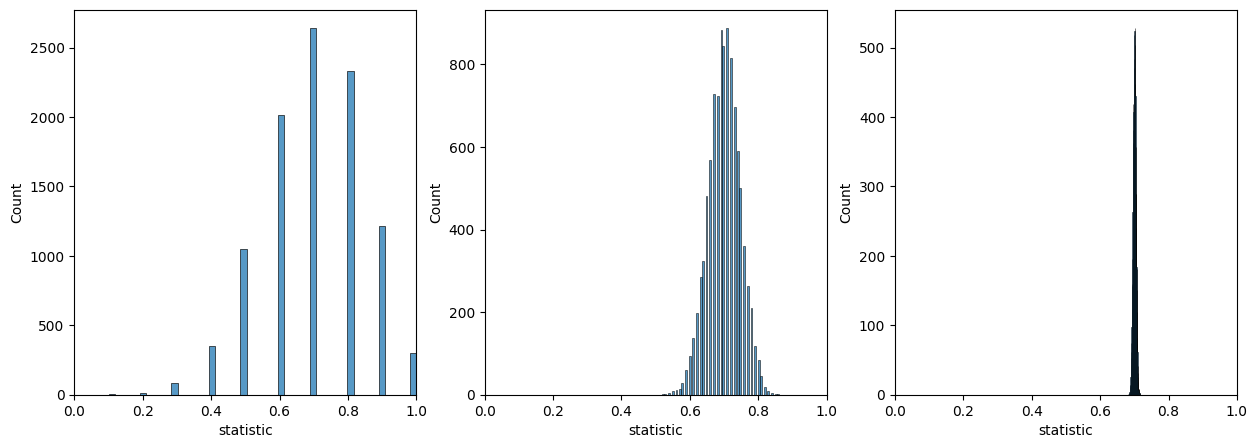

In [21]:
# make a figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# plot the bar plot on each subplot
plot_discrete(small, ax1, min_x=0, max_x=1)
plot_discrete(medium, ax2, min_x=0, max_x=1)
plot_discrete(large, ax3, min_x=0, max_x=1)

In [22]:
# compute the variance of the sampling distributions
small["statistic"].var(), medium["statistic"].var(), large["statistic"].var()

(np.float64(0.02109063296329633),
 np.float64(0.0021048793669366933),
 np.float64(2.0636401316531646e-05))

In [23]:
# Law of Large Numbers

# The codes above demonstrates the concept of the Law of Large Numbers, which states that:
    # - the sampling distribution of the mean has the same mean as the underlying distribution's mean
    # - as the size of a sample from a population increases, the variance goes down. That is, the mean 
    #   value of the sample will tend to be closer to the mean value of the population.

# In the context of voter polling, this means that as you poll more and more voters, your estimate of the proportion of voters 
# who will vote for a particular candidate will become more accurate.
# The law of large numbers means the analogous statement is also true for samples from any other distribution.

# do the analogous thing for samples from a poisson distribution
def sample_poisson(lam=1, n=1000):
    data = rng.poisson(lam=lam, size=n)
    return pd.DataFrame(data, columns=["Outcome"])

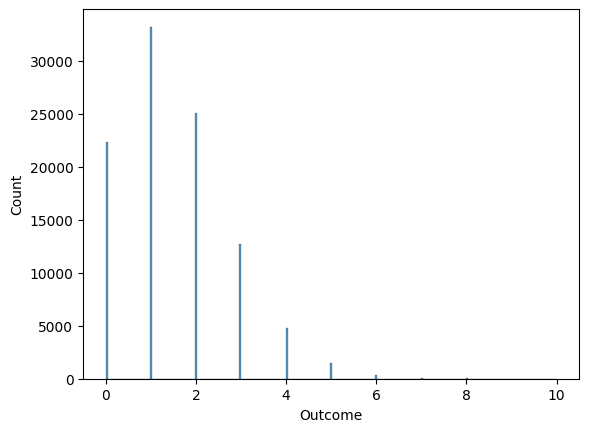

In [24]:
plot_discrete(sample_poisson(lam=1.5, n=100000), plt.gca(), colname="Outcome")

In [25]:
# package up the demonstration of the impact of sample size into a function, so we don't repeat ourselves
def show_effect_of_sample_size(
    sample_sizes, sample_statistic, underlying_distribution_simulator, n_simulations=1000
):
    # simulate sampling distributions for each sample size
    sampling_distributions = [
        simulate_sampling_distribution(
            underlying_distribution_simulator=underlying_distribution_simulator,
            sample_statistic=sample_statistic,
            n_simulations=n_simulations,
            sample_size=n,
        )
        for n in sample_sizes
    ]

    # make a figure with a subplot for each sample size
    fig, axes = plt.subplots(1, len(sample_sizes), figsize=(5 * len(sample_sizes), 5))

    # plot the bar plot on each subplot
    for ax, sampling_distribution, sample_size in zip(
        axes, sampling_distributions, sample_sizes
    ):
        plot_discrete(sampling_distribution, ax, num_ticks=6, min_x=0, max_x=4)
        ax.set_title(f"Sample size = {sample_size}")

    # compute the variance of the sampling distributions
    return [
        sampling_distribution["statistic"].var()
        for sampling_distribution in sampling_distributions
    ]

[np.float64(0.14853180908090807),
 np.float64(0.01487524700870087),
 np.float64(0.001516857858225822)]

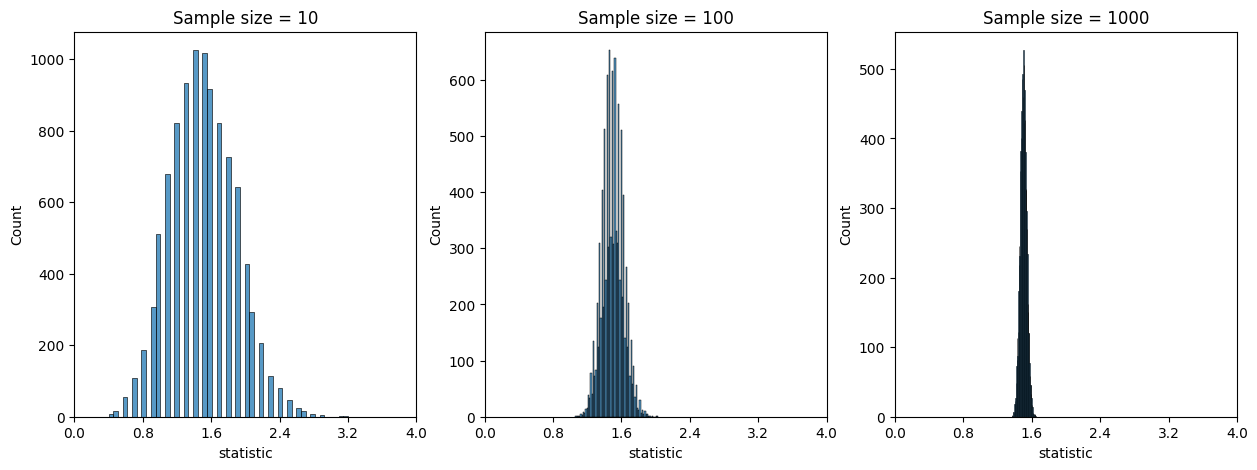

In [26]:
# changes in variances for 3 different sample sizes
show_effect_of_sample_size(
    sample_sizes=[10, 100, 1000],
    sample_statistic=lambda df: df["Outcome"].mean(),
    underlying_distribution_simulator=lambda n: sample_poisson(lam=1.5, n=n),
    n_simulations=10000,
)

# As shown the mean stays the same for all three cases, but the variance decreases as the sample size increases.

In [27]:
# 3. Bootstrap Sampling

# Simulating Bootstrap Samples

# Suppose that, instead of having a simulator for the underlying distribution that generated data, all we have is a sample of data. 
# If we think that data was a random sample from the population, we can generate another random sample from the population by taking 
# a random sample from the original sample. It's called a resample.

# To build intuitions, suppose we have a standard deck of 52 playing cards.
    # If we want to deal a random 5-card poker hand, we could shuffle the deck well and take the top 5 cards.
    # Alternatively, we could shuffle the deck and keep only the top half, 26 cards, and call it our original sample. 
    #     Without looking at those 26 cards, we could shuffle them and deal the top five.
    #     That subsample of five would be just as "random" as taking the top five cards from the full deck.

# Now, if we want to generate many random 5-card poker hands that are just like we would have gotten from dealing from the 52-card deck, 
# we can deal from the set of 26 many times. We will use a process called sampling with replacement.
# After we deal one hand of five cards, we put those cards back in and reshuffle before dealing another hand (not like playing an actual game of poker!)
#     Actually, we go one step farther. After we deal each card, we put it back and reshuffle the 26 cards.

#     You may be bothered by this process, for a couple reasons:
#         You might get the Ace of Spades more than once in a single five-card hand, because of the "with replacement" process.
#         If the King of Hearts is not in the original sample of 26 cards, it will never appear in any of the five-card hands that you simulate.

#     But it turns out this sampling with replacement process works pretty well for statistical inference about the sampling distribution in many settings.
#         Usually, we don't care about duplicating particular items or making sure that every item in the population has an equal chance of appearing in the samples.
#         Instead, we care about the samples having the same statistical properties that samples drawn from the population would have:
#             - same mean.
#             - independence from other samples.
#         In most cases, sampling with replacement will do that well. In particular, the "with replacement" approach does a better job of assuring independence between samples.

# Because sampling with replacement is useful statistically, the software libraries we use have that capability built in!


# rng.choice()

# In particular, rng.choice() can be used to sample from an existing dataframe.
    # It returns a new dataframe with a specified number of rows selected from the existing dataframe
    # If replace=True is specified, after each row is selected, it is replaced and is possibly available again as the next choice

def bootstrap_resample(arr, n_rows):
    return rng.choice(arr, n_rows, replace=True)


In [28]:
# Let's try it with half a deck of cards (represented as the numbers 1-52)
random_half_deck = rng.choice(np.arange(1,53), 26, replace=False)
random_half_deck

array([28, 42, 15, 12,  8, 11, 30, 32, 20, 35, 44, 36, 46,  4, 21, 48, 14,
        5, 40, 39,  7, 16, 22, 45,  1, 33])

In [29]:
random_half_deck.mean()

np.float64(25.153846153846153)

In [30]:
for _ in range(5):
    print(bootstrap_resample(random_half_deck, 5))

[35  5 11 35 33]
[39 44  8 22 39]
[22  1 36  5 14]
[32 33 22 40 14]
[22 11 20 32 48]


In [31]:
# Using Bootstrap Samples to Simulate the Sampling Distribution of the Mean

sampling_dist_1 = simulate_sampling_distribution(
    underlying_distribution_simulator = lambda n: bootstrap_resample(random_half_deck, n),
    sample_statistic = np.mean,
    n_simulations=10000,
    sample_size=5
)


sampling_dist_1.describe()

,statistic
count,10000.000000
mean,25.110780
std,6.496361
min,4.400000
25%,20.600000
50%,25.200000
75%,29.600000
max,46.000000


In [32]:
# Let's see if the sampling distribution is very different than we would have gotten from sampling from a full deck

full_deck = np.arange(1, 53)
sampling_dist_2 = simulate_sampling_distribution(
    underlying_distribution_simulator = lambda n: bootstrap_resample(full_deck, n),
    sample_statistic = np.mean,
    n_simulations=10000,
    sample_size=5
)

sampling_dist_2.describe()


,statistic
count,10000.000000
mean,26.438180
std,6.677283
min,3.000000
25%,21.800000
50%,26.600000
75%,31.200000
max,49.600000


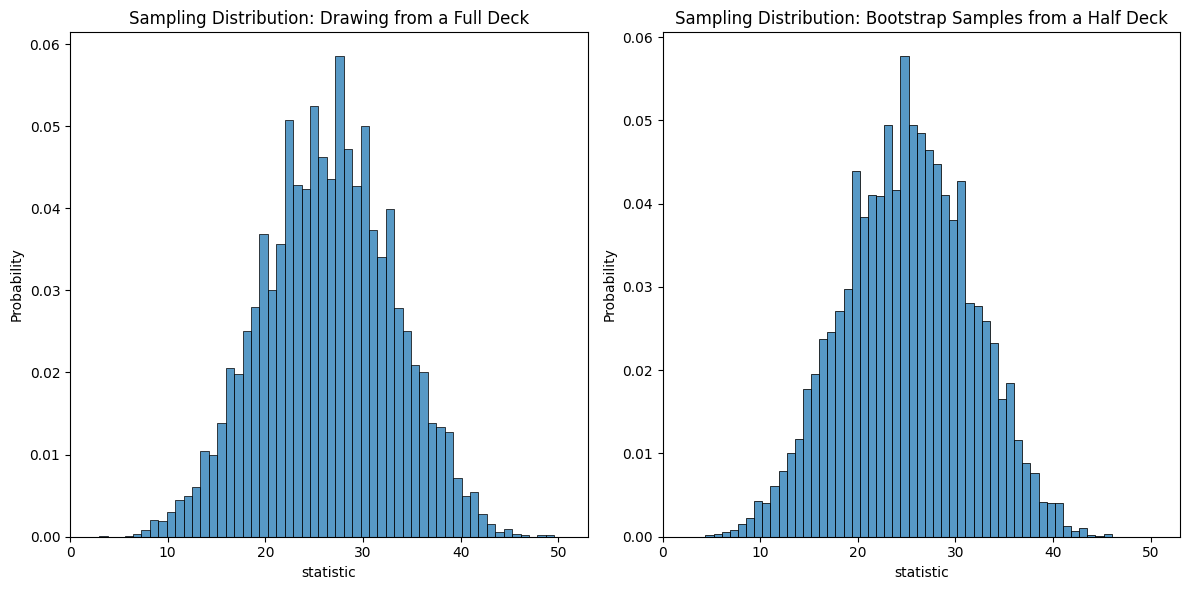

In [33]:
# plot the histogram of a dataset generated from a continuous distribution, by binning the data
def plot_continuous(data, ax, colname="statistic", num_bins=100, min_x=None, max_x=None):
    sns.histplot(data[colname], ax=ax, stat="probability")

    # Set the range of the x-axis if min_x and max_x are provided
    if min_x is not None and max_x is not None:
        ax.set_xlim(min_x, max_x)

    ax.set_ylabel("Probability")



# use plot_continuous to plot both sampling distributions side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
plot_continuous(sampling_dist_1, ax2, min_x=0, max_x=53)
ax2.set_title("Sampling Distribution: Bootstrap Samples from a Half Deck")
plot_continuous(sampling_dist_2, ax1, min_x=0, max_x=53)
ax1.set_title("Sampling Distribution: Drawing from a Full Deck")
plt.tight_layout()
plt.show()

In [34]:
# The sampling distributions came out pretty close, vindicating our approach of bootstrap sampling.
# It's a little risky, though.
    # Imagine we had gotten unlucky and our initial half-deck was quite unrepresentative.


weird_half_deck = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 52])
sampling_dist_3 = simulate_sampling_distribution(
    underlying_distribution_simulator = lambda n: bootstrap_resample(weird_half_deck, n),
    sample_statistic = np.mean,
    n_simulations=10000,
    sample_size=5
)
sampling_dist_3.describe()


,statistic
count,10000.000000
mean,14.501020
std,4.598721
min,2.800000
25%,11.400000
50%,14.000000
75%,17.000000
max,38.000000


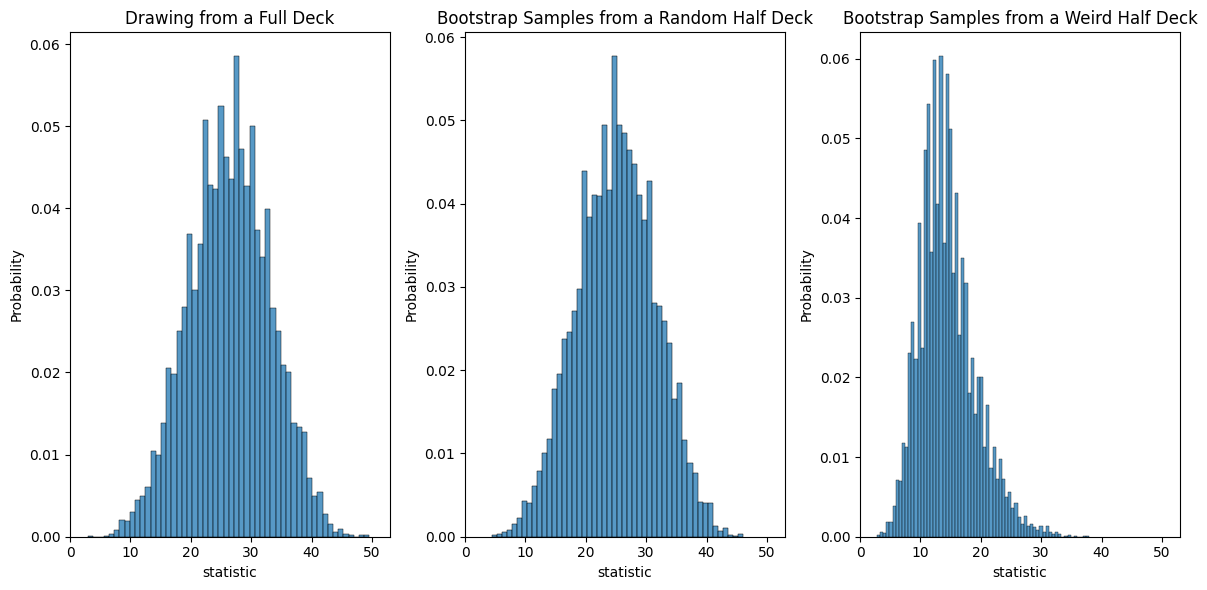

In [35]:
# use plot_continuous to plot all three sampling distributions side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 6))
plot_continuous(sampling_dist_1, ax2, min_x=0, max_x=53)
ax2.set_title("Bootstrap Samples from a Random Half Deck")
plot_continuous(sampling_dist_2, ax1, min_x=0, max_x=53)
ax1.set_title("Drawing from a Full Deck")
plot_continuous(sampling_dist_3, ax3, min_x=0, max_x=53)
ax3.set_title("Bootstrap Samples from a Weird Half Deck")
plt.tight_layout()
plt.show()

In [36]:
# The Central Limit Theorem

# In a previous lesson we saw the law of large numbers. It states that when we look at the sampling distribution of the mean, the mean will be 
# the same as the mean of the underlying distribution.
    # For example, if we flip 10 coins again and again, we won't get 5 every time. But we'll get an average of 5 if we do it lots of times.

# And the standard deviation of the sampling distribution gets smaller as the size of the samples gets bigger.
    # For example, if we flip 100 coins lots of times, most of the results will be closer to 50% heads than if we flip 10 coins lots of times. 
    # And if we flip 100,000 coins, while we won't get exactly 50,000, we'll get pretty close to 50% heads.


# The Central Limit Theorem states something else. It says that the sampling distribution of the mean always approaches the shape of a normal 
# distribution as the sample sizes get bigger, regardless of the shape of the original distribution. It's a pretty remarkable result!

# Let's see how that looks empirically for some underlying distributions that we've seen before, including ones that are really far from normal distributions.


def simulate_clt(
    underlying_distribution_simulator,  # function that simulates the underlying distribution, returning a dataframe with a column named "Outcome"
    discrete=True,  # whether the underlying distribution is discrete or continuous; affects our plot of the underlying distribution
    n_simulations=1000,
):
    # Create a figure with 4 subplots
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    plt.subplots_adjust(wspace=0.5)

    # Simulate the underlying distribution
    underlying_distribution_df = underlying_distribution_simulator(n_simulations)

    min_x = underlying_distribution_df["Outcome"].min()
    max_x = underlying_distribution_df["Outcome"].max()

    # Plot the underlying distribution on the first axes object
    ax = axes[0]
    if discrete:
        plot_discrete(underlying_distribution_df, ax, colname="Outcome", min_x=min_x, max_x=max_x)
    else:
        plot_continuous(underlying_distribution_df, ax, colname="Outcome", min_x=min_x, max_x=max_x)
    ax.set_title("Underlying Distribution")
    ax.set_xlabel("")


    # plot figures for sampling distribution of the mean for samples of size 5, 50, and 500
    for ax, sample_size in zip(axes[1:], [5, 50, 500]):
        # Simulate the sampling distribution
        sample_statistics_df = simulate_sampling_distribution(
            underlying_distribution_simulator,
            sample_statistic=lambda df: df["Outcome"].mean(),
            n_simulations=n_simulations,
            sample_size=sample_size,
        )

        plot_continuous(
            sample_statistics_df,
            ax,
            colname="statistic",
            min_x=min_x,
            max_x=max_x,
        )
        ax.set_title(f"mean of n={sample_size}")
        ax.set_xlabel("")

    # Display the plot
    plt.show()




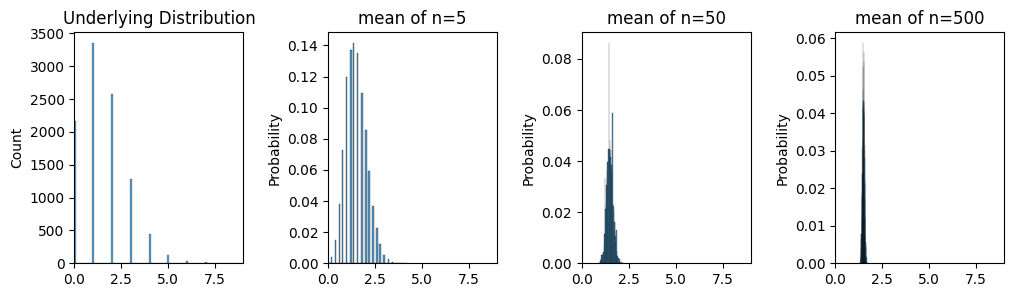

In [37]:
# Simulate sample means for increasing sample sizes for Poisson with lambda = 1.5
simulate_clt(
    underlying_distribution_simulator=lambda n: pd.DataFrame(
        rng.poisson(lam=1.5, size=n), columns=["Outcome"]
    ),
    n_simulations=10000,
    discrete=True,
    )

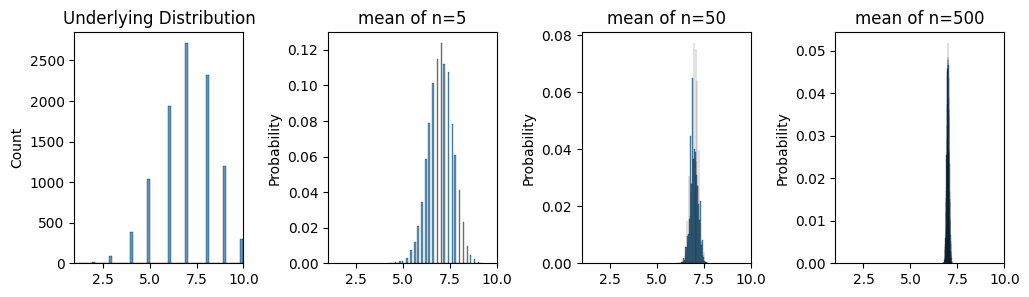

In [38]:
# Let's try it for the binomial distribution: count of heads in 10 coin flips, with probability 0.7 on each flip.
simulate_clt(
    underlying_distribution_simulator=lambda n: pd.DataFrame(
        rng.binomial(n=10, p=0.7, size=n), columns=["Outcome"]
    ),
    n_simulations=10000,
    discrete=True,
)

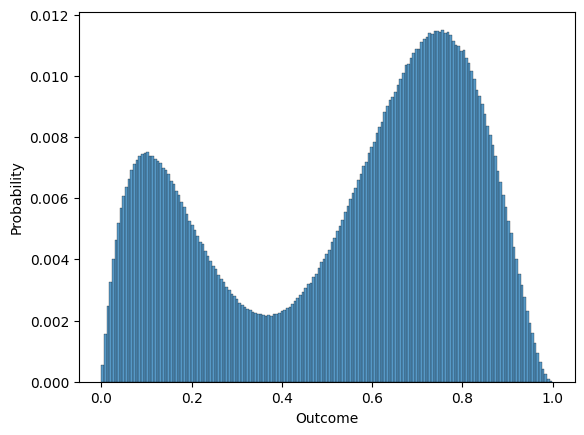

In [39]:
# Now for our first continuous distribution, one with two "humps"

def sample_mix_of_two_betas(alpha1=1, beta1=5, alpha2=5, beta2=1, mix=0.5, n=1000):
    which = rng.choice([1, 2], size=n, p=[mix, 1 - mix])
    b1 = rng.beta(alpha1, beta1, n)
    b2 = rng.beta(alpha2, beta2, n)
    df = pd.DataFrame({"Outcome": np.where(which == 1, b1, b2)})
    return df


plot_continuous(sample_mix_of_two_betas(2, 10, 7, 3, mix=0.3, n=5000000), plt.gca(), colname="Outcome")

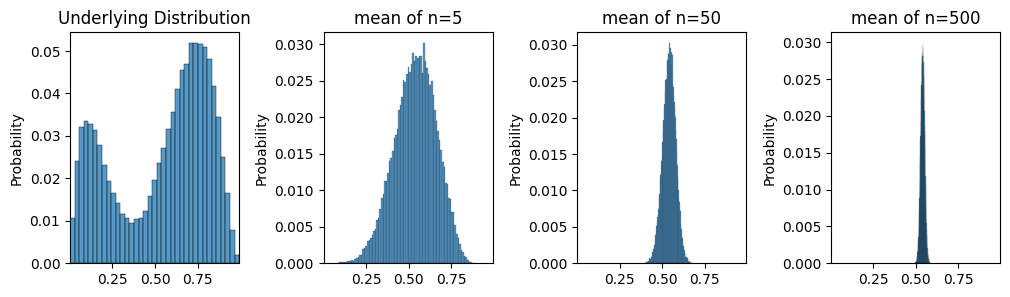

In [40]:
simulate_clt(
    underlying_distribution_simulator=lambda n: pd.DataFrame(
        sample_mix_of_two_betas(2, 10, 7, 3, mix=0.3, n=n), columns=["Outcome"]
    ),
    n_simulations=50000,
    discrete=False,
)

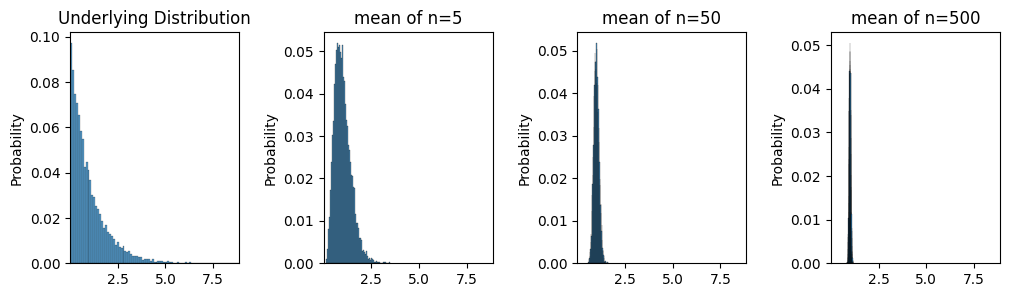

In [41]:
# And for an exponential distribution

simulate_clt(
    underlying_distribution_simulator=lambda n: pd.DataFrame(
        np.random.default_rng().exponential(scale=1, size=n), columns=["Outcome"]
    ),
    n_simulations=10000,
    discrete=False,
)